# 7-A. 전국 net_load → 가스 발전 예측 (LGBM)

> PROJECT.md §4 7단계 / 검증목표 2. 동시점 회귀 `gen_gas_kr = f(net_load, 기온, 달력)`.
> **베이스라인(net_load 단독 등위회귀) → LGBM** 비교로 추가 피처의 기여를 분리한다.

- 학습창(G-10): **train 2022–2024 / val 2025 / test 2026**. 2020–2021은 결측-0이라 로드 시 제외.
- 피처(§0.6 사용자 확정 = 설계 A 분해형): `real_demand_land`(수요) + `renew_gen_total_kr`(신재생) + `day_type` + 달력 `hour/dow/month/doy`. net_load는 수요−신재생으로 내포. 기온·`year` 제외.
- 분해형을 택한 이유: 신재생을 명시해 **대체효과(신재생↑→가스↓)** 를 부분의존도로 직접 보고, 제주 7-B와 같은 basis로 비교하기 위함. 예측력은 net_load+수요(설계 C)와 동률(R²≈0.78), B(net_load+신재생)는 수요 부재로 0.61로 급락.
- 모델: LGBM(트리). PatchTST는 시퀀스 예측용(2·3단계)이라 동시점 회귀엔 불필요.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import lightgbm as lgb
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mpl.rcParams['figure.dpi']=110; mpl.rcParams['axes.grid']=True; mpl.rcParams['font.size']=10
FIG=Path('fig'); FIG.mkdir(exist_ok=True); TAB=Path('tab'); TAB.mkdir(exist_ok=True)
DATA=Path('../../1. data_fetcher_and_db/second_dataset/data/land_full.parquet')

NUM=['real_demand_land','renew_gen_total_kr','hour','dow','month','doy']
CAT=['day_type']; FEATS=NUM+CAT; TARGET='gen_gas_kr'

df=pd.read_parquet(DATA); df['timestamp']=pd.to_datetime(df['timestamp'])
df=df[df['timestamp']>='2022-01-01'].dropna(subset=FEATS+[TARGET]).copy()   # G-10 필터
df['day_type']=df['day_type'].astype('category')

def split(a,b):
    m=(df['timestamp']>=a)&(df['timestamp']<b); return df[m]
tr=split('2022-01-01','2025-01-01'); va=split('2025-01-01','2026-01-01'); te=split('2026-01-01','2027-01-01')
print('train',len(tr),'| val',len(va),'| test',len(te))
print('test 기간', te['timestamp'].min(),'->',te['timestamp'].max())


train 26214 | val 8709 | test 3596
test 기간 2026-01-01 00:00:00 -> 2026-06-05 13:00:00


In [2]:
def metrics(y,p):
    return dict(MAE=mean_absolute_error(y,p),
                RMSE=mean_squared_error(y,p)**0.5,
                MAPE=np.mean(np.abs((y-p)/y))*100,
                R2=r2_score(y,p))
Xtr,ytr=tr[FEATS],tr[TARGET]; Xva,yva=va[FEATS],va[TARGET]; Xte,yte=te[FEATS],te[TARGET]


## 1. 베이스라인 — 수요 단독 등위회귀(단조)
수요(가장 강한 단일 동인)만으로 얼마나 설명되나. 추가 피처(신재생·달력)의 기여를 가늠하는 기준선.

In [3]:
iso=IsotonicRegression(increasing=True,out_of_bounds='clip').fit(tr['real_demand_land'],ytr)
base_va=iso.predict(va['real_demand_land']); base_te=iso.predict(te['real_demand_land'])
m_base_va=metrics(yva.values,base_va); m_base_te=metrics(yte.values,base_te)
print('베이스라인 val :',{k:round(v,2) for k,v in m_base_va.items()})
print('베이스라인 test:',{k:round(v,2) for k,v in m_base_te.items()})


베이스라인 val : {'MAE': 2937.19, 'RMSE': 3627.0, 'MAPE': 18.63, 'R2': 0.65}
베이스라인 test: {'MAE': 2842.57, 'RMSE': 3682.2, 'MAPE': 13.96, 'R2': 0.63}


## 2. LGBM — 전체 피처

In [4]:
params=dict(objective='regression_l1', n_estimators=2000, learning_rate=0.03,
            num_leaves=63, min_child_samples=50, subsample=0.8, subsample_freq=1,
            colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
model=lgb.LGBMRegressor(**params)
model.fit(Xtr,ytr, eval_set=[(Xva,yva)], eval_metric='l1',
          categorical_feature=CAT,
          callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
print('best_iteration', model.best_iteration_)
pred_va=model.predict(Xva); pred_te=model.predict(Xte)
m_lgb_va=metrics(yva.values,pred_va); m_lgb_te=metrics(yte.values,pred_te)
print('LGBM val :',{k:round(v,2) for k,v in m_lgb_va.items()})
print('LGBM test:',{k:round(v,2) for k,v in m_lgb_te.items()})


Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[163]	valid_0's l1: 2224.68
best_iteration 163
LGBM val : {'MAE': 2224.68, 'RMSE': 2795.02, 'MAPE': 13.62, 'R2': 0.79}
LGBM test: {'MAE': 2236.3, 'RMSE': 2819.89, 'MAPE': 11.43, 'R2': 0.78}


## 3. 결과 비교

In [5]:
res=pd.DataFrame({
 ('baseline','val'):m_base_va,('baseline','test'):m_base_te,
 ('LGBM','val'):m_lgb_va,('LGBM','test'):m_lgb_te}).T.round(2)
res.index=['baseline·val','baseline·test','LGBM·val','LGBM·test']
res.to_csv(TAB/'metrics.csv')
print(res.to_string())
imp_red=(1-m_lgb_te['MAE']/m_base_te['MAE'])*100
print(f'\nLGBM이 베이스라인 대비 test MAE {imp_red:.1f}% 개선')
res


                   MAE     RMSE   MAPE    R2
baseline·val   2937.19  3627.00  18.63  0.65
baseline·test  2842.57  3682.20  13.96  0.63
LGBM·val       2224.68  2795.02  13.62  0.79
LGBM·test      2236.30  2819.89  11.43  0.78

LGBM이 베이스라인 대비 test MAE 21.3% 개선


,MAE,RMSE,MAPE,R2
baseline·val,2937.19,3627.00,18.63,0.65
baseline·test,2842.57,3682.20,13.96,0.63
LGBM·val,2224.68,2795.02,13.62,0.79
LGBM·test,2236.30,2819.89,11.43,0.78


## 4. 예측 vs 실제 (test 2026)

C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:5: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'ts_test.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:5: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'ts_test.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:5: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'ts_test.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:5: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'ts_test.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:5: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s)

C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

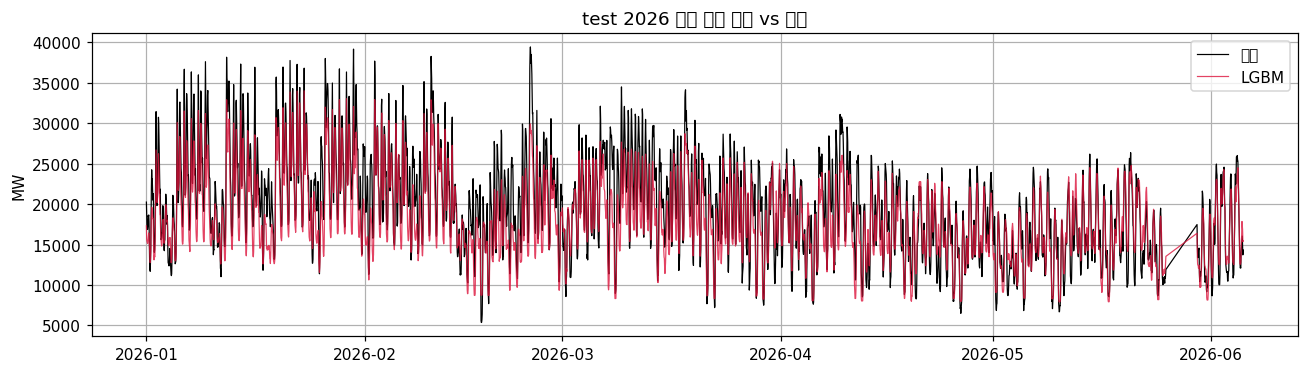

C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:13: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'pred_scatter_resid.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:13: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'pred_scatter_resid.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:13: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'pred_scatter_resid.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:13: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'pred_scatter_resid.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3323687751.py:13: UserWarning: Glyph 493

C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

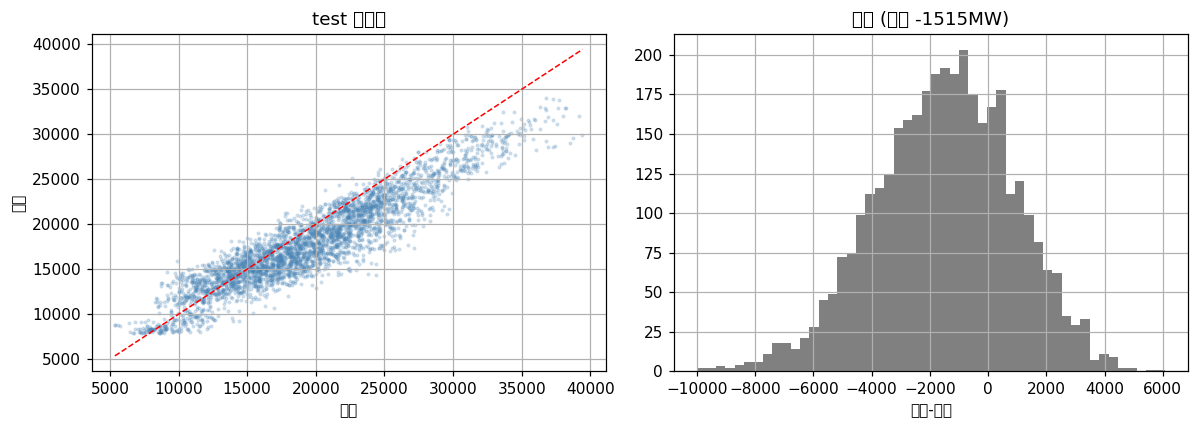

In [6]:
fig,ax=plt.subplots(figsize=(12,3.5))
ax.plot(te['timestamp'],yte.values,label='실제',lw=0.8,color='black')
ax.plot(te['timestamp'],pred_te,label='LGBM',lw=0.8,color='crimson',alpha=0.8)
ax.set_title('test 2026 가스 발전 예측 vs 실제'); ax.set_ylabel('MW'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'ts_test.png'); plt.show()

fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].scatter(yte,pred_te,s=3,alpha=0.2,color='steelblue')
lims=[yte.min(),yte.max()]; ax[0].plot(lims,lims,'r--',lw=1)
ax[0].set_xlabel('실제'); ax[0].set_ylabel('예측'); ax[0].set_title('test 산점도')
resid=pred_te-yte.values
ax[1].hist(resid,bins=50,color='gray'); ax[1].set_title(f'잔차 (평균 {resid.mean():.0f}MW)'); ax[1].set_xlabel('예측-실제')
plt.tight_layout(); plt.savefig(FIG/'pred_scatter_resid.png'); plt.show()


## 5. 피처 중요도

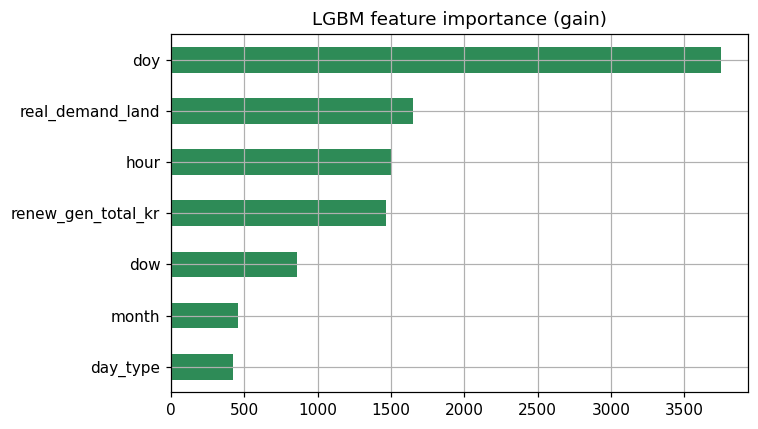

doy                   3746
real_demand_land      1650
hour                  1507
renew_gen_total_kr    1464
dow                    858
month                  456
day_type               425
dtype: int32

In [7]:
imp=pd.Series(model.feature_importances_,index=FEATS).sort_values()
fig,ax=plt.subplots(figsize=(7,4))
imp.plot.barh(ax=ax,color='seagreen'); ax.set_title('LGBM feature importance (gain)')
plt.tight_layout(); plt.savefig(FIG/'importance.png'); plt.show()
imp.sort_values(ascending=False)


## 6. 부분의존도 — 수요·신재생의 한계효과 (대체효과 확인)
다른 피처는 데이터 분포대로 두고 한 피처만 격자로 바꿔 예측 평균. 신재생 곡선이 우하향이면 대체효과.

C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3735714311.py:16: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'pdp.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3735714311.py:16: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'pdp.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3735714311.py:16: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'pdp.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3735714311.py:16: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'pdp.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_8036\3735714311.py:16: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.

C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

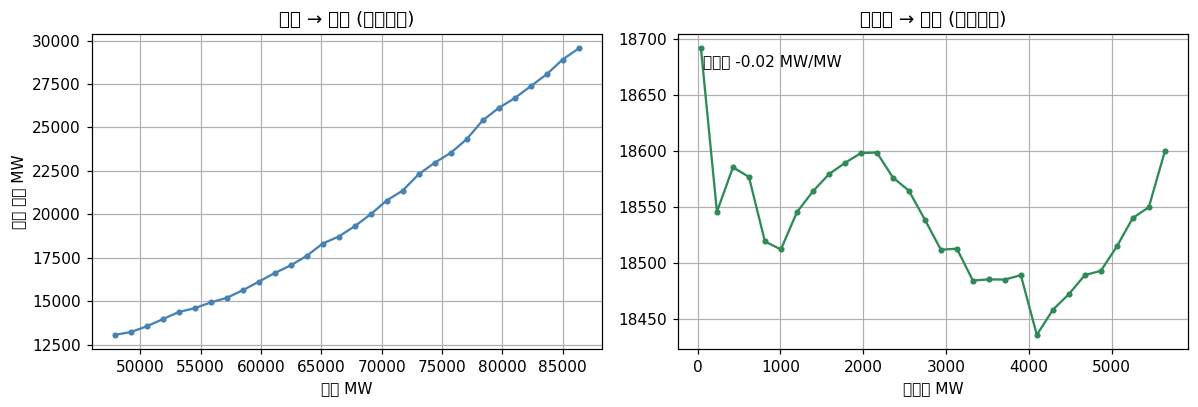

신재생 부분의존 기울기 = -0.017 MW/MW (음수면 대체효과; 전국은 침투율 낮아 약함)


In [8]:
def pdp(feat, grid):
    out=[]
    base=Xtr.sample(min(3000,len(Xtr)),random_state=0).copy()
    for v in grid:
        b=base.copy(); b[feat]=v; out.append(model.predict(b).mean())
    return np.array(out)
gd_dem=np.linspace(tr['real_demand_land'].quantile(.02),tr['real_demand_land'].quantile(.98),30)
gd_rnw=np.linspace(tr['renew_gen_total_kr'].quantile(.02),tr['renew_gen_total_kr'].quantile(.98),30)
pd_dem=pdp('real_demand_land',gd_dem); pd_rnw=pdp('renew_gen_total_kr',gd_rnw)

fig,ax=plt.subplots(1,2,figsize=(11,3.8))
ax[0].plot(gd_dem,pd_dem,'-o',ms=3,color='steelblue'); ax[0].set_title('수요 → 가스 (한계효과)'); ax[0].set_xlabel('수요 MW'); ax[0].set_ylabel('예측 가스 MW')
ax[1].plot(gd_rnw,pd_rnw,'-o',ms=3,color='seagreen'); ax[1].set_title('신재생 → 가스 (한계효과)'); ax[1].set_xlabel('신재생 MW')
slope=np.polyfit(gd_rnw,pd_rnw,1)[0]
ax[1].text(0.05,0.9,f'기울기 {slope:+.2f} MW/MW',transform=ax[1].transAxes)
plt.tight_layout(); plt.savefig(FIG/'pdp.png'); plt.show()
print(f'신재생 부분의존 기울기 = {slope:+.3f} MW/MW (음수면 대체효과; 전국은 침투율 낮아 약함)')


## 7. 요약 (실행 후 수치 자동 표기)
- 검증목표 2(전국 net_load → 가스): test 2026 실측으로 정직 평가.
- baseline(net_load 단독) 대비 LGBM 개선폭 = 추가 피처(기온·달력·day_type)의 기여.
- 다음: **7-B 제주 probe**(2020–2024 only_gen 실측 + net_load별 LNG 추정), **7-C KOGAS 환산**.


In [9]:
# 모델·메타 저장
model.booster_.save_model('lgbm_land_gas.txt')
import json
json.dump({'features':FEATS,'target':TARGET,'best_iteration':int(model.best_iteration_),
           'window':'train 2022-2024 / val 2025 / test 2026',
           'metrics_test_lgbm':{k:round(v,3) for k,v in m_lgb_te.items()},
           'metrics_test_baseline':{k:round(v,3) for k,v in m_base_te.items()}},
          open('model_meta.json','w',encoding='utf-8'),ensure_ascii=False,indent=2)
print('saved lgbm_land_gas.txt, model_meta.json')


saved lgbm_land_gas.txt, model_meta.json
